In [80]:
pip install geopandas fiona shapely pyproj rtree

In [81]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [82]:
# Load the CSV file and print some information

df = pd.read_csv("aviation-accidents.csv")

print(df.head())

        date             type registration       operator fatalities  \
0  date unk.   Antonov An-12B       T-1206  Indonesian AF        NaN   
1  date unk.   Antonov An-12B       T-1204  Indonesian AF        NaN   
2  date unk.   Antonov An-12B       T-1201  Indonesian AF        NaN   
3  date unk.  Antonov An-12BK          NaN      Soviet AF        NaN   
4  date unk.  Antonov An-12BP   CCCP-11815      Soviet AF          0   

              location          country cat     year  
0                  NaN  Unknown country  U1  unknown  
1                  NaN  Unknown country  U1  unknown  
2                  NaN  Unknown country  U1  unknown  
3  Tiksi Airport (IKS)           Russia  A1  unknown  
4  Massawa Airport ...          Eritrea  A1  unknown  


In [83]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          23967 non-null  object
 1   type          23967 non-null  object
 2   registration  22419 non-null  object
 3   operator      23963 non-null  object
 4   fatalities    20029 non-null  object
 5   location      23019 non-null  object
 6   country       23967 non-null  object
 7   cat           23967 non-null  object
 8   year          23967 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB
None


In [84]:
print(df.describe())

               date                  type registration operator fatalities  \
count         23967                 23967        22419    23963      20029   
unique        15079                  3201        21944     6017        369   
top     10-MAY-1940  Douglas C-47A (DC-3)       LZ-...    USAAF          0   
freq            171                  1916           13     2604      10713   

       location country    cat   year  
count     23019   23967  23967  23967  
unique    14608     232     11    106  
top     unknown     USA     A1   1944  
freq        272    4377  17424   1505  


In [85]:
# Clean invalid or null data

from dateutil import parser

def parse_date(date_str):
    for fmt in ('%d-%b-%Y', '%Y-%m-%d', '%d/%m/%Y'):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT  # If no format is valid, returns NaT

In [86]:
# When a column contains dates, let Pandas interpret them
df['date'] = df['date'].apply(parse_date)

# Verify that the conversion was successful
print(df['date'].head())
print(df['date'].dtypes)

0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
Name: date, dtype: datetime64[ns]
datetime64[ns]


In [87]:
# Ensure that 'fatalities' is of numeric type
df['fatalities'] = pd.to_numeric(df['fatalities'], errors='coerce')

# Replace infinite values with NaN throughout the DataFrame
df.replace([float('inf'), float('-inf')], pd.NA, inplace=True)

# Verify that there are no more infinite values present
print("Valori infiniti presenti:", df.isin([float('inf'), float('-inf')]).sum().sum())

# Also replace NaT values with NaN
df['date'] = df['date'].replace({pd.NaT: pd.NaT})

# Remove rows with NaN or NaT that could cause problems in the graphs
df.dropna(subset=['date', 'fatalities', 'country', "registration", "operator", "location"], inplace=True)

# Verify the presence of NaN and infinite values.
print("Valori NaN presenti:")
print(df.isna().sum())
print("Valori infiniti presenti:")
print(df.isin([float('inf'), float('-inf')]).sum())

# Check that the columns used in the graphs do not have infinite or NaN values.
df = df.dropna(subset=['date', 'fatalities', 'country', 'operator', 'type', "registration", "location"])

Valori infiniti presenti: 0
Valori NaN presenti:
date            0
type            0
registration    0
operator        0
fatalities      0
location        0
country         0
cat             0
year            0
dtype: int64
Valori infiniti presenti:
date            0
type            0
registration    0
operator        0
fatalities      0
location        0
country         0
cat             0
year            0
dtype: int64


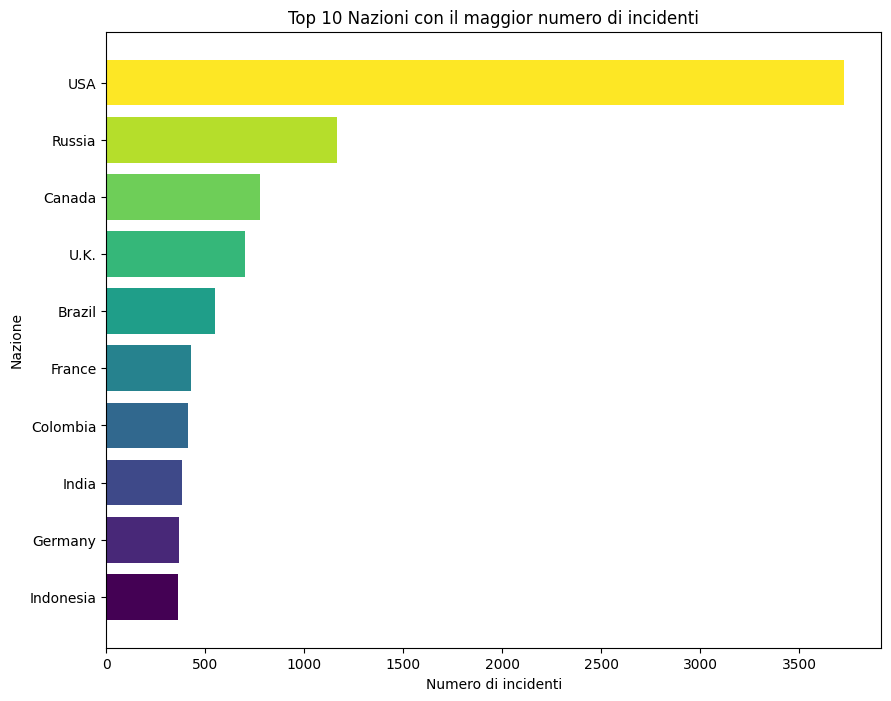

In [88]:
# To find out which are the 10 countries with the highest number of incidents,
# calculate the incidents for each country and, by sorting them in descending order, get the top 10.
# This is how the graph is created:
incidents_per_country = df['country'].value_counts().reset_index()
incidents_per_country.columns = ['country', 'incidents']
incidents_per_country = incidents_per_country.sort_values(by='incidents', ascending=False)

# Select the top 10 countries and reverse the order to have the bars in descending order.
top_10_countries = incidents_per_country[:10]
top_10_countries = top_10_countries.iloc[::-1]

colors = plt.cm.viridis(np.linspace(0, 1, len(top_10_countries['country'])))

plt.figure(figsize=(10, 8))
plt.barh(top_10_countries['country'], top_10_countries['incidents'], color=colors)
plt.title('Top 10 Nazioni con il maggior numero di incidenti')
plt.xlabel('Numero di incidenti')
plt.ylabel('Nazione')
plt.show()

#1. Top 10 Nazioni con il Maggior Numero di Incidenti

#Questo grafico mostra le prime 10 Nazioni con il maggior numero di incidenti aerei registrati.
#È un grafico a barre orizzontali dove l'asse y rappresenta le nazioni e l'asse x rappresenta il
#numero di incidenti. Questo tipo di grafico è utile per identificare rapidamente i Paesi con il
#maggior numero di incidenti e aiutare ad effettuare ulteriori analisi su questi Paesi per
#capire i motivi dietro l'alto numero di incidenti.
#Nel caso specifico è evidente che gli USA hanno registrato un numero significativamente elevato di
#incidenti rispetto ad altri Paesi. Ciò verrà confermato successivamente anche dalla Heat Map.
#Una delle cause potrebbe essere l'elevato traffico aereo all'interno del Paese.

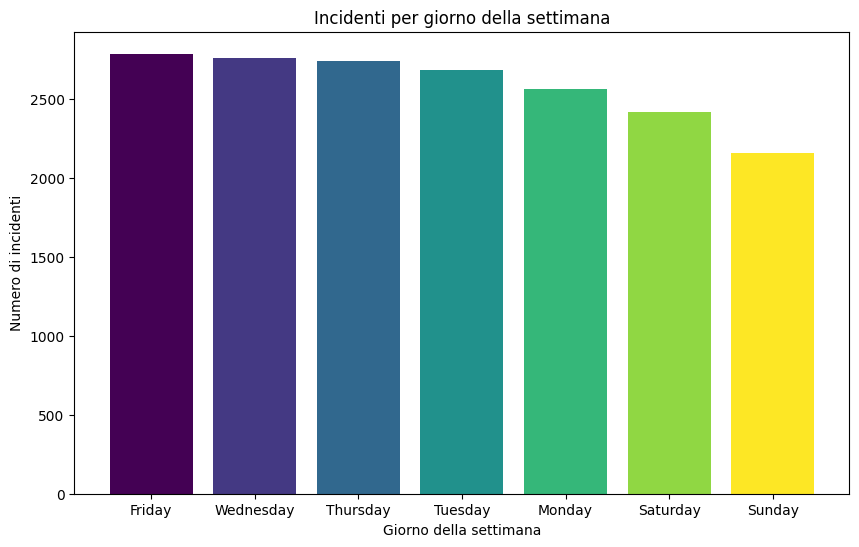

In [89]:
# To create the "incidents per day of the week" chart, verify that the 'date'
#column is in datetime format and create the chart:
if pd.api.types.is_datetime64_any_dtype(df['date']):
    df['day_of_week'] = df['date'].dt.day_name()

    # Count the incidents per day of the week and sort
    incidents_per_day = df['day_of_week'].value_counts().sort_index().reset_index()
    incidents_per_day.columns = ['day_of_week', 'incidents']
    incidents_per_day = incidents_per_day.sort_values(by='incidents', ascending=False)

    colors = plt.cm.viridis(np.linspace(0, 1, len(incidents_per_day['day_of_week'])))

    plt.figure(figsize=(10, 6))
    plt.bar(incidents_per_day['day_of_week'], incidents_per_day['incidents'], color=colors)
    plt.title('Incidenti per giorno della settimana')
    plt.xlabel('Giorno della settimana')
    plt.ylabel('Numero di incidenti')
    plt.show()
else:
    print("Errore: la colonna 'date' non è in formato datetime.")

#2. Incidenti per Giorno della Settimana

#Questo grafico mostra il numero di incidenti aerei per ciascun giorno della settimana.
#È un grafico a barre verticali dove l'asse x rappresenta i giorni della settimana e
#l'asse y rappresenta il numero di incidenti. Questo grafico può aiutare a identificare
#se ci sono giorni specifici della settimana in cui gli incidenti sono più frequenti.
#Nel caso specifico gli incidenti si registrano maggiormente nei giorni feriali, mentre
#scemano durante il fine settimana, questo potrebbe indicare un aumento del traffico aereo
#o altre condizioni specifiche che meritano ulteriori indagini.

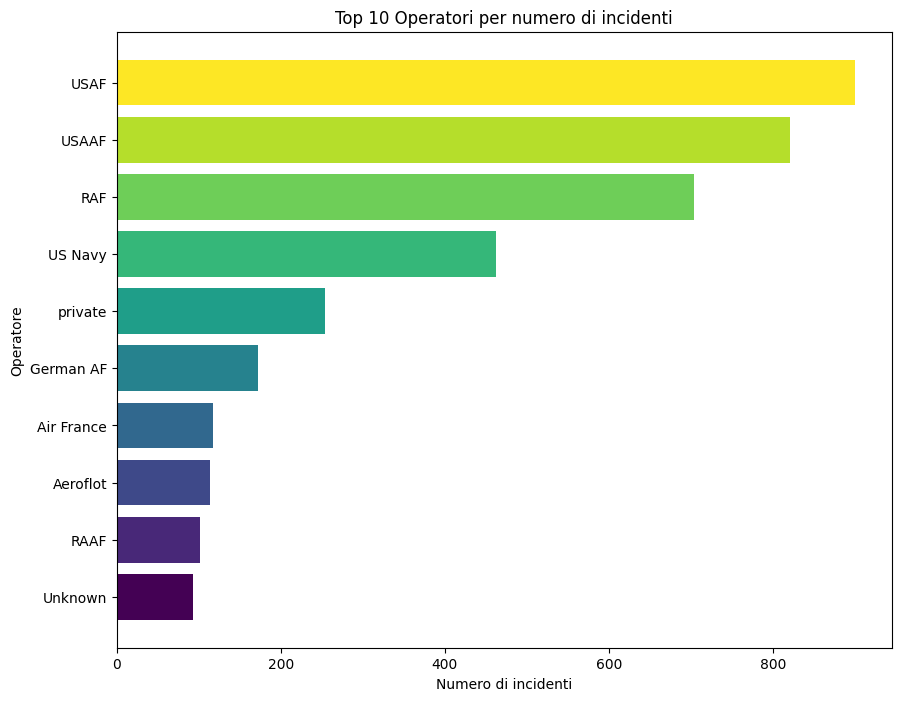

In [90]:
# Use "value_counts()" again to count the frequency of incidents per operator.
# The function sorts them in descending order, so I get the top 10 operators
#with the most incidents:
operators_incidents = df['operator'].value_counts().reset_index()
operators_incidents.columns = ['operator', 'incidents']
operators_incidents = operators_incidents.sort_values(by='incidents', ascending=False)

# Select the top 10 operators and reverse the order to have the bars in descending order
top_10_operators = operators_incidents[:10]
top_10_operators = top_10_operators.iloc[::-1]

colors = plt.cm.viridis(np.linspace(0, 1, len(top_10_operators['operator'])))

plt.figure(figsize=(10, 8))
plt.barh(top_10_operators['operator'], top_10_operators['incidents'], color=colors)
plt.title('Top 10 Operatori per numero di incidenti')
plt.xlabel('Numero di incidenti')
plt.ylabel('Operatore')
plt.show()

#3. Top 10 Operatori per Numero di Incidenti

#Questo grafico mostra i primi 10 operatori (compagnie aeree) con il maggior numero di
#incidenti aerei. Come il primo grafico, è un grafico a barre orizzontali dove l'asse y
#rappresenta gli operatori e l'asse x rappresenta il numero di incidenti. Questo grafico
#è utile per identificare quali compagnie aeree (nel caso specifico USAF, USAAF e RAF)
#hanno avuto più incidenti e può servire come punto di partenza per analizzare le
#pratiche di sicurezza di queste compagnie.

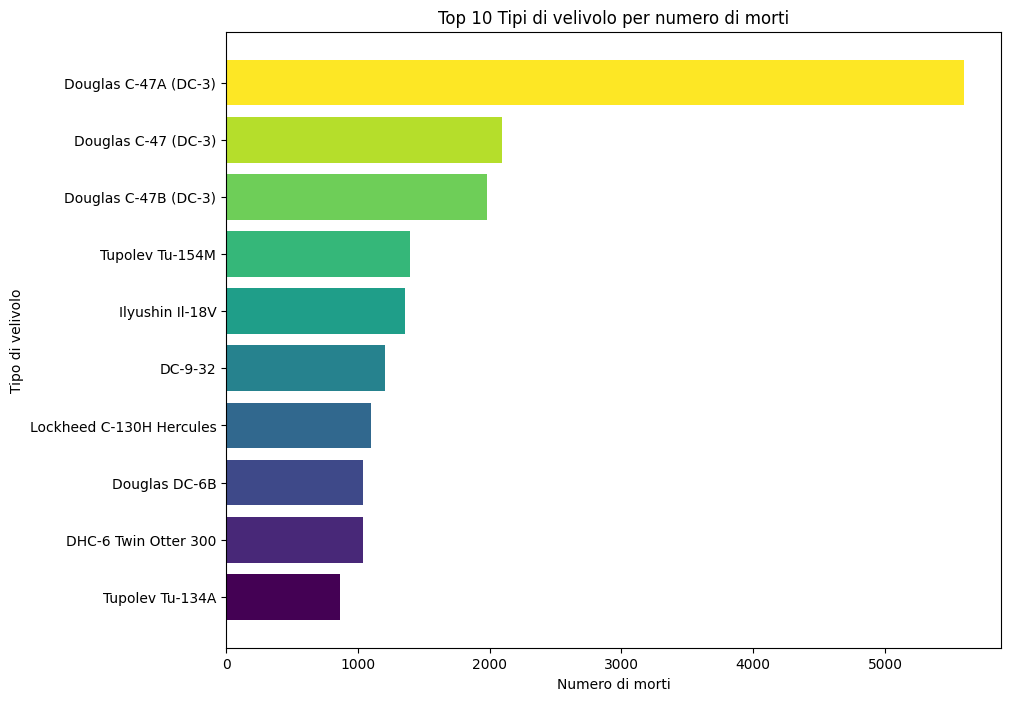

In [91]:
# Group the number of fatalities by vehicle and, by sorting them in descending
#order, get the top 10 with the most fatalities:

aircraft_fatalities = df.groupby('type')['fatalities'].sum().sort_values(ascending=False).reset_index()
top_10_aircraft_fatalities = aircraft_fatalities.iloc[:10][::-1]

colors = plt.cm.viridis(np.linspace(0, 1, len(top_10_aircraft_fatalities['type'])))

plt.figure(figsize=(10, 8))
plt.barh(top_10_aircraft_fatalities['type'], top_10_aircraft_fatalities['fatalities'], color=colors)
plt.title('Top 10 Tipi di velivolo per numero di morti')
plt.xlabel('Numero di morti')
plt.ylabel('Tipo di velivolo')
plt.show()

#4. Top 10 Tipi di Velivolo per Numero di Morti

#Questo grafico mostra i primi 10 tipi di velivolo che hanno causato il maggior numero
#di morti. È un grafico a barre orizzontali dove l'asse y rappresenta i tipi di velivolo
#e l'asse x rappresenta il numero di morti. Questo tipo di analisi identifica i modelli
#di velivolo che potrebbero aver avuto problemi di sicurezza significativi e può aiutare
#a indirizzare le indagini su specifici modelli di aeromobili. In particolare il velicolo
#"Douglas C-47A (DC-3)" è quello che ha registrato più incidenti, mentre, tra i primi 10,
#il velivolo "Tupolev Tu-134A" pare il più sicuro.

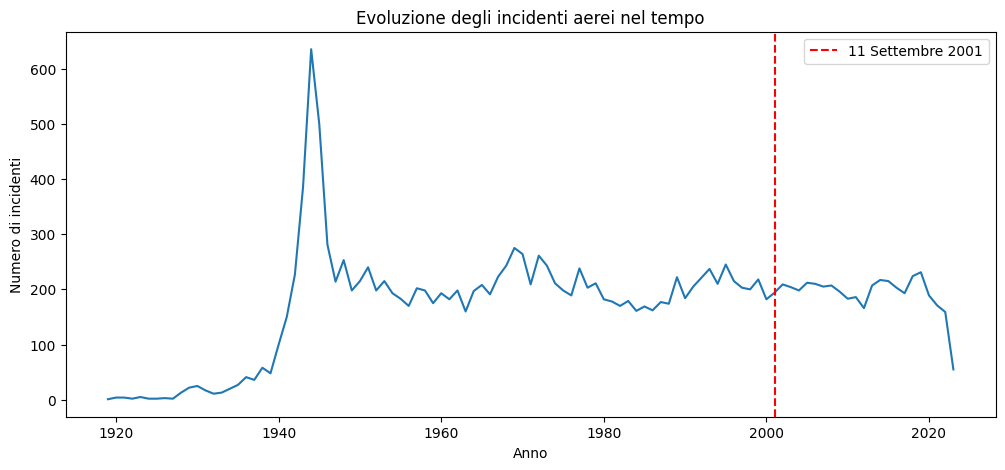

In [92]:
# Create a line chart to show the trend of air incidents over time, including
# the date of September 11, 2001, to visualize the frequency of incidents after that date.

df['year'] = df['date'].dt.year
incidents_per_year = df['year'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
sns.lineplot(x=incidents_per_year.index, y=incidents_per_year.values)
plt.axvline(x=2001, color='red', linestyle='--', label='11 Settembre 2001')
plt.title('Evoluzione degli incidenti aerei nel tempo')
plt.xlabel('Anno')
plt.ylabel('Numero di incidenti')
plt.legend()
plt.show()

#5. Evoluzione degli Incidenti Aerei nel Tempo

#Questo grafico a linee mostra l'evoluzione del numero di incidenti aerei nel tempo,
#dal 1919 al 2023. L'asse x rappresenta gli anni e l'asse y rappresenta il numero di
#incidenti. La linea rossa tratteggiata evidenzia l'11 settembre 2001, un punto chiave
#nella storia dell'aviazione. In effetti dopo tale data si nota una diminuzione
#degli incidenti, probabilmente a seguito di miglioramenti nelle pratiche di sicurezza.

In [93]:
# To create a Heat Map, load the map using a shapefile (.shp), which is a
# geospatial file format mainly used in geographic information systems (GIS) to
# store the location, shape, and attributes of geographic features
world = gpd.read_file("ne_110m_admin_0_countries.shp")

# After an initial attempt to create the map, I notice a discrepancy between
# USA and United States of America in the two DataFrames, so I verify:
print(df['country'].unique())
print(world['ADMIN'].unique())

['U.K.' 'South Africa' 'Sudan' 'Sweden' 'India' 'France' 'Belgium'
 'Netherlands' 'Atlantic Ocean' 'Germany' 'USA' 'Italy' 'Cuba' 'Iran'
 'Chile' 'Israel' 'Argentina' 'Nicaragua' 'Czech Rep.' 'Dominican Rep.'
 'Brazil' 'Mediterranean Sea' 'Indonesia' 'Egypt' 'Honduras' 'Bolivia'
 'Spain' 'Peru' 'Australia' 'Poland' 'Iraq' 'Malta' 'Colombia'
 'Switzerland' 'Austria' 'China' 'Mexico' 'Trinidad & Tobago' 'Norway'
 'Greece' 'Libya' 'Guatemala' 'Algeria' 'Pakistan' 'Panama' 'Romania'
 'Morocco' 'Bulgaria' 'Pacific Ocean' 'Russia' 'Jamaica' 'Kenya' 'Hungary'
 'Canada' 'Gambia' 'Philippines' 'Japan' 'Ecuador' 'Puerto Rico'
 'Mozambique' 'Singapore' 'Myanmar' 'Djibouti' 'Gibraltar' 'Indian Ocean'
 'Denmark' 'Finland' 'Estonia' 'Vietnam' 'Tanzania' 'Iceland' 'Benin'
 'Costa Rica' 'Portugal' 'P.N. Guinea' 'Uzbekistan' 'Ethiopia' 'Nigeria'
 'Belarus' 'Ukraine' 'Turkmenistan' 'Ireland' 'Hong Kong' 'Kazakhstan'
 'Sierra Leone' 'U.S. M.O. Islands' 'Unknown country' 'Mauritania'
 'Vanuatu' 'New Caled

In [94]:
# I correct this:
country_mapping = {'USA': 'United States of America'}
# And apply the mapping to the incidents DataFrame
df['country'] = df['country'].replace(country_mapping)

# Verify that the term "United States of America" is present in both DataFrames:
print(df['country'].unique())
print(world['ADMIN'].unique())

['U.K.' 'South Africa' 'Sudan' 'Sweden' 'India' 'France' 'Belgium'
 'Netherlands' 'Atlantic Ocean' 'Germany' 'United States of America'
 'Italy' 'Cuba' 'Iran' 'Chile' 'Israel' 'Argentina' 'Nicaragua'
 'Czech Rep.' 'Dominican Rep.' 'Brazil' 'Mediterranean Sea' 'Indonesia'
 'Egypt' 'Honduras' 'Bolivia' 'Spain' 'Peru' 'Australia' 'Poland' 'Iraq'
 'Malta' 'Colombia' 'Switzerland' 'Austria' 'China' 'Mexico'
 'Trinidad & Tobago' 'Norway' 'Greece' 'Libya' 'Guatemala' 'Algeria'
 'Pakistan' 'Panama' 'Romania' 'Morocco' 'Bulgaria' 'Pacific Ocean'
 'Russia' 'Jamaica' 'Kenya' 'Hungary' 'Canada' 'Gambia' 'Philippines'
 'Japan' 'Ecuador' 'Puerto Rico' 'Mozambique' 'Singapore' 'Myanmar'
 'Djibouti' 'Gibraltar' 'Indian Ocean' 'Denmark' 'Finland' 'Estonia'
 'Vietnam' 'Tanzania' 'Iceland' 'Benin' 'Costa Rica' 'Portugal'
 'P.N. Guinea' 'Uzbekistan' 'Ethiopia' 'Nigeria' 'Belarus' 'Ukraine'
 'Turkmenistan' 'Ireland' 'Hong Kong' 'Kazakhstan' 'Sierra Leone'
 'U.S. M.O. Islands' 'Unknown country' 'Mauritania'

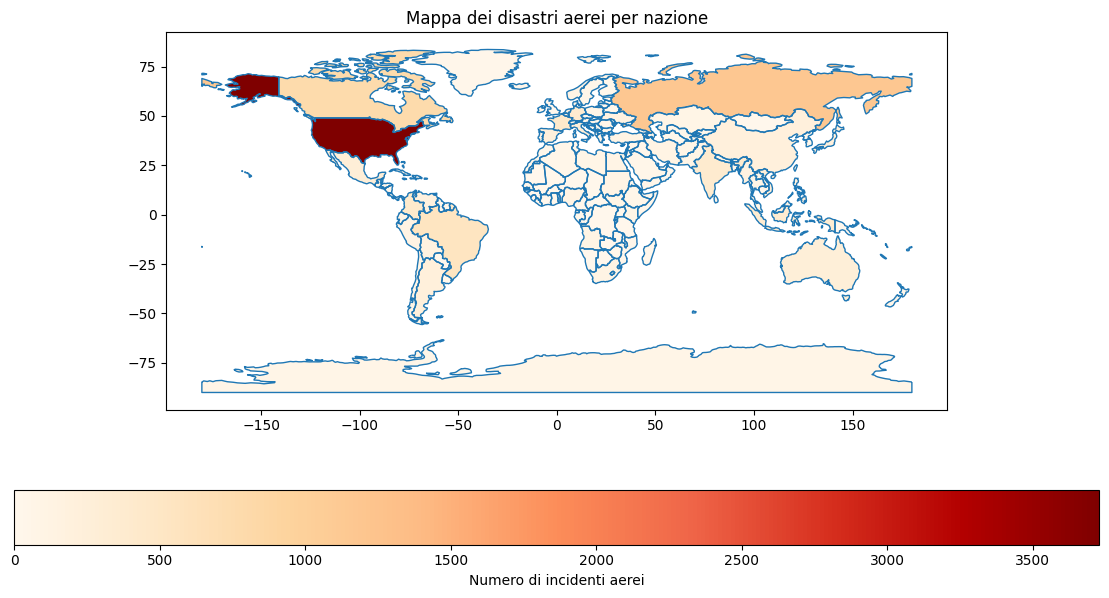

In [95]:
# Now, I can proceed with counting the incidents per country:
incidents_per_country = df['country'].value_counts().reset_index()
incidents_per_country.columns = ['country', 'incidents']

# Merge the incidents DataFrame with the geographic data
world = world.merge(incidents_per_country, how='left', left_on='ADMIN', right_on='country')

# Replace NaN values with 0 (countries with no incidents)
world['incidents'] = world['incidents'].fillna(0)

# Create the cartogram:
plt.figure(figsize=(14, 7))

# Plot the world boundaries
world.boundary.plot(ax=plt.gca(), linewidth=1)

# Define the map
world.plot(column='incidents', cmap='OrRd', legend=True,
           legend_kwds={'label': "Numero di incidenti aerei",
                        'orientation': "horizontal"},
           ax=plt.gca())
plt.title('Mappa dei disastri aerei per nazione')
plt.show()

#6. Mappa dei Disastri Aerei per Nazione

#Questo cartogramma mostra la distribuzione geografica del numero di incidenti aerei
#per nazione. Utilizza una mappa del mondo dove ogni nazione è colorata in base al numero
#di incidenti aerei registrati. Le nazioni con un numero maggiore di incidenti sono
#colorate con tonalità più scure. Questo grafico è utile per visualizzare la distribuzione
#globale degli incidenti aerei e per ad esempio, vedere che nazioni con un elevato traffico
#aereo hanno più incidenti rispetto a #nazioni con meno traffico.
#Nel caso specifico si conferma quanto visto nel grafico a barre "Top 10 Nazioni con il
#Maggior Numero di Incidenti", cioè gli USA hanno registrato pià incidenti.

In [96]:
# OTHER CHARTS

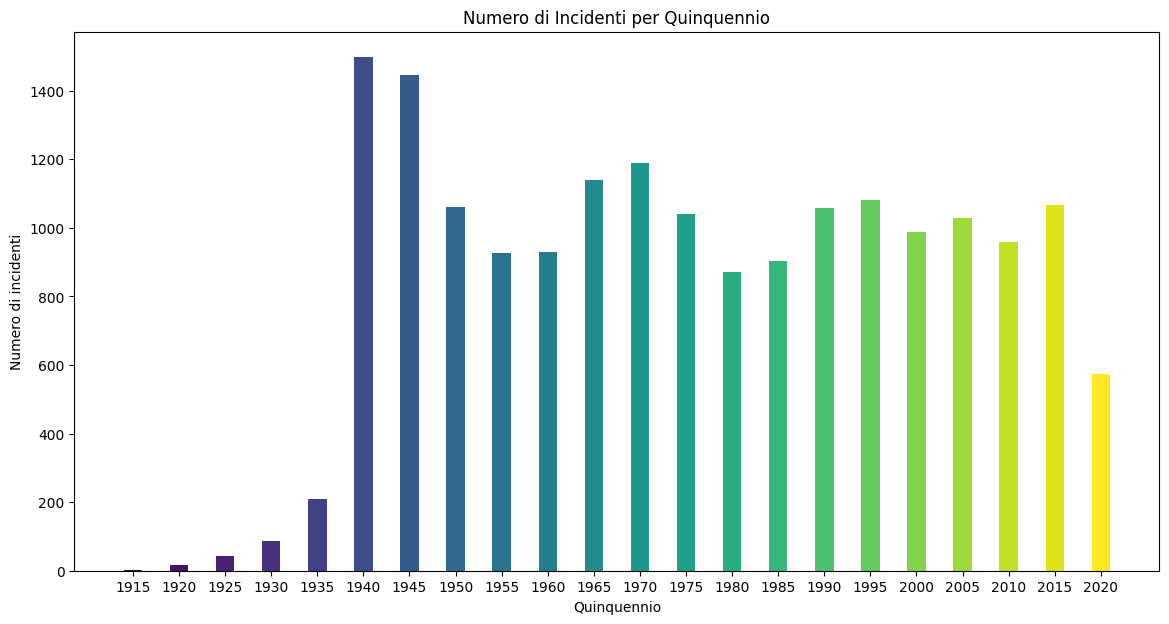

In [97]:
#Numero di Incidenti per Quinquennio
#Il grafico risultante mostrerà la distribuzione degli incidenti aerei per quinquennio,
#consentendo di visualizzare le tendenze e i pattern nel tempo. Questo grafico può rivelare
#periodi di aumento o diminuzione degli incidenti, permettendo di indagare ulteriormente
#su eventuali cause o fattori associati.
#Nello specifico gli anni '40 hanno registrato più incidenti aerei, coincidente con la fine
#della Seconda Guerra Mondiale.

# Add a column for the five-year period
df['quinquennio'] = (df['year'] // 5) * 5

# Count the number of incidents per five-year period
incidents_per_quinquennio = df['quinquennio'].value_counts().sort_index().reset_index()
incidents_per_quinquennio.columns = ['quinquennio', 'incidents']

colors = plt.cm.viridis(np.linspace(0, 1, len(incidents_per_quinquennio)))

# Create the bar chart
plt.figure(figsize=(14, 7))
plt.bar(incidents_per_quinquennio['quinquennio'], incidents_per_quinquennio['incidents'], color=colors, width=2)
plt.title('Numero di Incidenti per Quinquennio')
plt.xlabel('Quinquennio')
plt.ylabel('Numero di incidenti')
plt.xticks(incidents_per_quinquennio['quinquennio'])
plt.show()

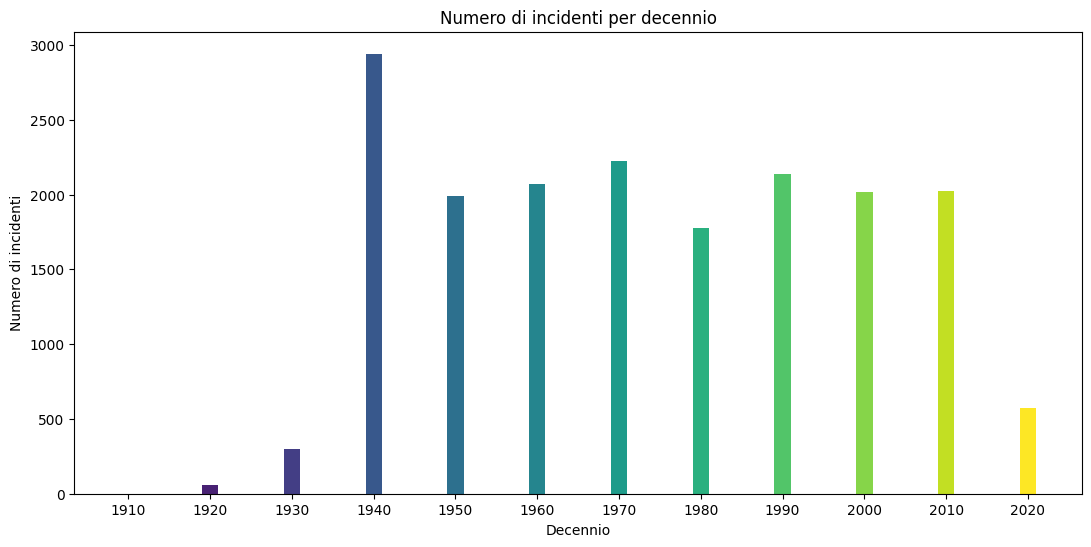

In [98]:
#Numero di Incidenti per Decennio
#Un grafico a barre che mostra la distribuzione degli incidenti per decennio.
#Simile a quello precedente, ma con classi formate da 10 anni.
#Nello specifico, anche in questo grafico si evidenzia che gli anni '40 hanno registrato più incidenti aerei.

df['decade'] = (df['year'] // 10) * 10
incidents_per_decade = df['decade'].value_counts().sort_index().reset_index()
incidents_per_decade.columns = ['decade', 'incidents']

colors = plt.cm.viridis(np.linspace(0, 1, len(incidents_per_decade)))

plt.figure(figsize=(13, 6))
plt.bar(incidents_per_decade['decade'], incidents_per_decade['incidents'], color=colors, width=2)
plt.title('Numero di incidenti per decennio')
plt.xlabel('Decennio')
plt.ylabel('Numero di incidenti')
plt.xticks(incidents_per_decade['decade'])
plt.show()

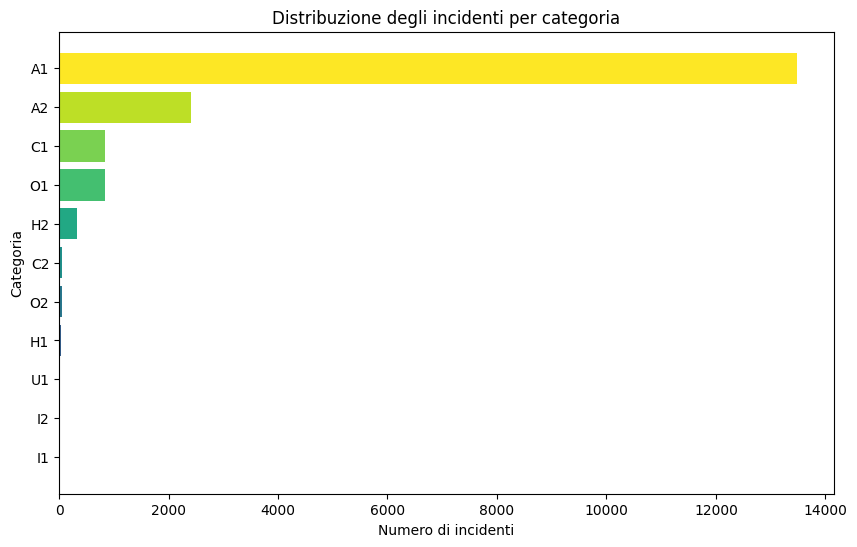

In [99]:
#Numero di Incidenti per Categoria:
#Identifica quali categorie di incidenti sono più frequenti, aiutando a focalizzare le strategie di prevenzione.
#Questo grafico a barre mostra la distribuzione degli incidenti aerei per categoria, dove ogni barra
#rappresenta il numero di incidenti per una specifica categoria. L'asse y rappresenta le categorie
#degli incidenti, mentre l'asse x rappresenta il numero di incidenti. Questo tipo di grafico è utile
#per capire quali categorie di incidenti sono più frequenti. Ad esempio, potremmo scoprire che
#incidenti causati da errori umani o guasti tecnici sono più comuni rispetto ad altri tipi di
#incidenti, il che potrebbe indirizzare ulteriori indagini e strategie di prevenzione.
#Nel caso specifico la categoria di incidente A1 è quella che ha registrato frequenza maggiore.

incidents_per_category = df['cat'].value_counts().reset_index()
incidents_per_category.columns = ['category', 'incidents']
incidents_per_category = incidents_per_category.sort_values(by='incidents', ascending=False)
incidents_per_category = incidents_per_category.iloc[::-1]

# Create a list of colors
colors = plt.cm.viridis(np.linspace(0, 1, len(incidents_per_category)))

plt.figure(figsize=(10, 6))
plt.barh(incidents_per_category['category'], incidents_per_category['incidents'], color=colors)
plt.title('Distribuzione degli incidenti per categoria')
plt.xlabel('Numero di incidenti')
plt.ylabel('Categoria')
plt.show()

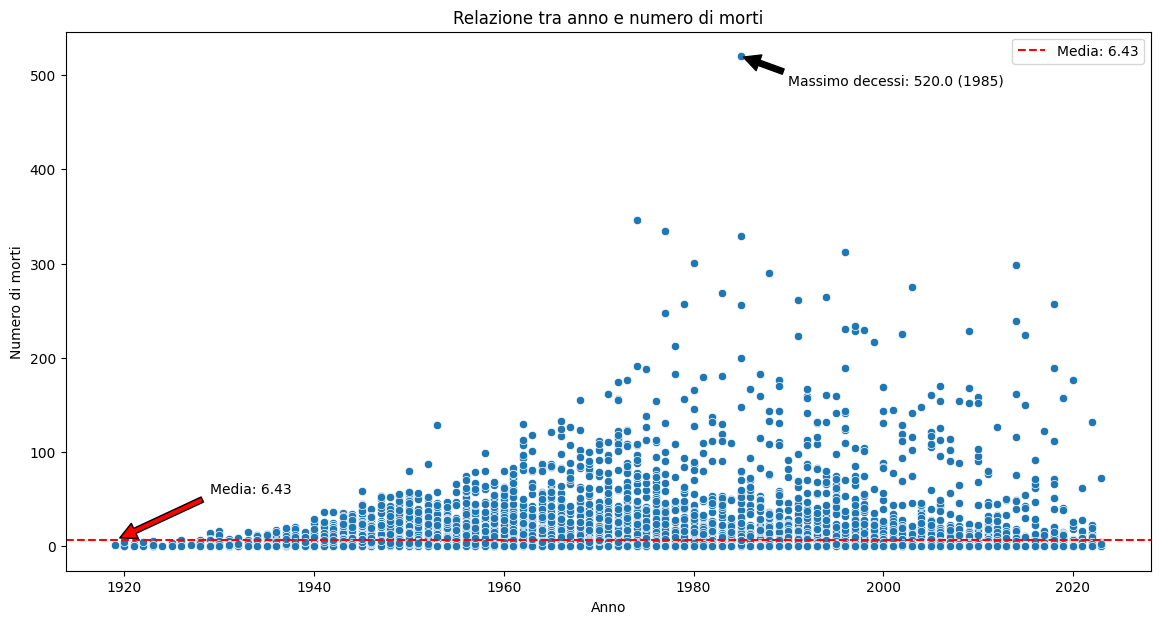

In [100]:
#Relazione tra Numero di Morti e Anno, con media dei decessi, numero massimo dei decessi e relativo anno.
#Il grafico risultante mostra la relazione tra l'anno e il numero di morti con uno scatterplot.
#Una linea rossa tratteggiata rappresenta la media dei decessi, e un'etichetta con freccia
#evidenzia sia la media che l'anno con il numero massimo di decessi nel grafico.
#Questo grafico visualizza come il numero di morti varia nel tempo, identifica periodi con un numero
#particolarmente alto o basso di decessi rispetto alla media.

# Calculate the average fatalities:
mean_fatalities = df['fatalities'].mean()

# Identify the year with the maximum number of fatalities:
max_fatalities = df['fatalities'].max()
max_fatalities_year = df.loc[df['fatalities'].idxmax(), 'year']

# Create the scatter plot:
plt.figure(figsize=(14, 7))
sns.scatterplot(x='year', y='fatalities', data=df)

# Add a horizontal line for the average and its label with an arrow:
plt.axhline(y=mean_fatalities, color='red', linestyle='--', label=f'Media: {mean_fatalities:.2f}')

plt.annotate(f'Media: {mean_fatalities:.2f}',
             xy=(df['year'].min(), mean_fatalities),
             xytext=(df['year'].min() + 10, mean_fatalities + 50),
             arrowprops=dict(facecolor='red', shrink=0.05))

# Add a label with an arrow to indicate the maximum number of fatalities:
plt.annotate(f'Massimo decessi: {max_fatalities} ({max_fatalities_year})',
             xy=(max_fatalities_year, max_fatalities),
             xytext=(max_fatalities_year + 5, max_fatalities - 30),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Define the chart title:
plt.title('Relazione tra anno e numero di morti')
plt.xlabel('Anno')
plt.ylabel('Numero di morti')
plt.legend()
plt.show()

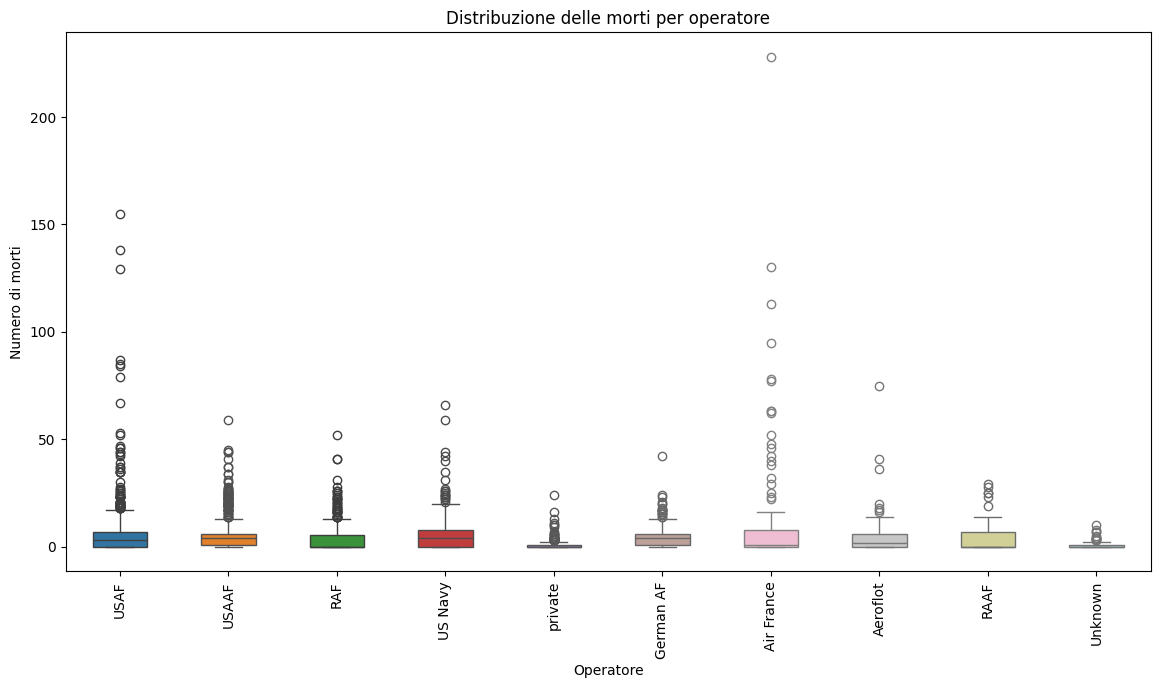

In [101]:
#Distribuzione delle Morti per Operatore:
#Evidenzia la variabilità nel numero di morti tra diversi operatori, permettendo di identificare operatori con maggiori rischi.
#Questo grafico a scatole (boxplot) mostra la distribuzione del numero di morti per i primi
#10 operatori (compagnie aeree) con il maggior numero di incidenti. L'asse x rappresenta gli
#operatori, mentre l'asse y rappresenta il numero di morti. Ogni scatola rappresenta la
#distribuzione dei decessi per un operatore specifico, con la linea centrale che indica la mediana,
#i bordi della scatola che rappresentano il 25° e il 75° percentile, e i baffi che estendono ai valori
#estremi. Questo grafico è utile per identificare la variabilità nel numero di morti tra diversi
#operatori e per evidenziare eventuali outlier (valori anomali). Ad esempio, un operatore con una
#scatola più alta potrebbe indicare una maggiore variabilità o un maggior numero di incidenti gravi.
#Se precedentemente si è analizzata la relazione tra Operatore e numero di incidenti, qui analizziamo
#piuttosto la gravità di tali incidenti, prendendo in analisi il numero dei decessi.

top_operators = df['operator'].value_counts().index[:10]
df_top_operators = df[df['operator'].isin(top_operators)]

colors = plt.cm.tab20(np.linspace(0, 1, len(top_operators)))

plt.figure(figsize=(14, 7))
for i, operator in enumerate(top_operators):
    sns.boxplot(x='operator', y='fatalities', data=df_top_operators[df_top_operators['operator'] == operator],
                color=colors[i], width=0.5)
plt.xticks(rotation=90)
plt.title('Distribuzione delle morti per operatore')
plt.xlabel('Operatore')
plt.ylabel('Numero di morti')
plt.show()